# iamge 증강



In [1]:
import torch
import torchvision.transforms as transforms

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

def show_image(img, title):
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    
image_path = 'dog.png'
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

## GlassBlur (글래스 블러)

- 이미지에 유리 효과를 적용하여 적용, 마치 유리를 통해 보는 것처럼 이미지를 흐리게 만드는 데이터 증강 기법
- 이미지에서 세부 정보를 의도적으로 감소시키고 싶을 떄 사용 
- Glassblur는 주로 데이터의 과적합을 줄이고, 모델이 다양한 시각적 효과에 강인하게 학습하도록 돕기 위해 사용 

### 작동 원리

- 이미지의 각 픽셀을 무작위로 이동시키는 방식 
- 특정 반경 내의 픽셀이 서로 섞이게 되어, 유리로 인해 발생하는 흐림 효과를 모방 
- 이는 이미지의 세부적인 텍스처와 패턴을 흐리게 하여, 이미지 내 명확한 구분이 어려워 질 수 있다. 

### 주요 파라미터 

- `sigma` : 흐림의 정도를 제어, 실제로는 유리 블러의 강도를 조절 
- `max_delta`: 픽셀을 이동시킬 최대 거리를 지정, 이 값이 클수록 더 많은 픽셀이 원래 위치에서 멀리 이동, 더 강한 흐림효과를 나타냄. 
- `iterations`: 파라미터는 블러를 적용하는 반복 횟수를 정의, 반복 횟수가 많을수록 이미지는 더욱 흐려임. 

/var/folders/ct/csn7gw6j4lzg64vvct28bvj00000gn/T/ipykernel_28367/3608501844.py:1: UserWarning: Argument(s) 'always_apply' are not valid for transform GlassBlur
  transform = A.GlassBlur(sigma=0.7, max_delta=4, iterations=2, always_apply=True)


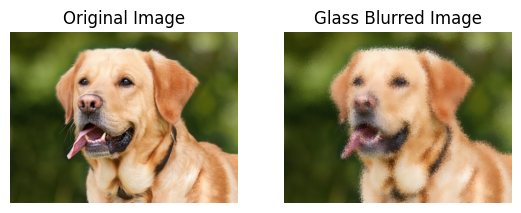

In [3]:
transform = A.GlassBlur(sigma=0.7, max_delta=4, iterations=2, always_apply=True)
    
augmented_image = transform(image=image_np)['image']
    
plt.figure(figsize=(10, 5)) 

plt.subplot(2, 3, 1) 
show_image(image_np, 'Original Image')

plt.subplot(2, 3, 2)  
show_image(augmented_image, 'Glass Blurred Image')

plt.show()

## CLAHE ( Contrast Limited Adaptive Histogram Equalization )

- 이미지의 대비를 개선하기 위한 고급 히스토그램 평준화 기법 
- 일반적인 히스토그램 평준화와는 달리 이미지 전체에 적용되는 것이 아니라, 이미지를 작은 구역(tiles)으로 나누고 각 구역에 대해 히스토그램 평준화를 적용 
- 의료영상, 위성영상 등에서 세부 사항이 중요한 이미지의 대비를 개선하는데 유용

### 작동원리

- 이미지를 작은 구역으로 나눔,
- 각 구역의 히스토그램을 계산하고, 지정된 대비 제한(Contrast limit)을 적용하여 극단적인 히스토그램의 빈도 수를 제한. 
- 히스토그램 평준화 시 발생할 수 있는 노이즈 증폭을 방지 
- 각 구역의 히스토그램을 평준화하여 대비를 개선 
- 구역 경계에서 발생할 수 있는 인공적인 경계선을 부드럽게 만들기 위해 인접 구역과의 보간을 수행 

/var/folders/ct/csn7gw6j4lzg64vvct28bvj00000gn/T/ipykernel_28367/2877383773.py:1: UserWarning: Argument(s) 'always_apply' are not valid for transform CLAHE
  transform = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), always_apply=True)


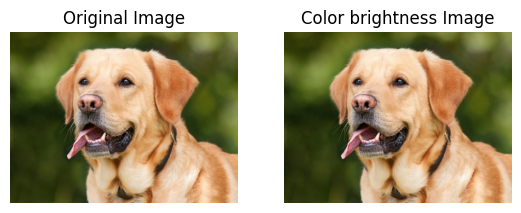

In [4]:
transform = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), always_apply=True)
# clip_limit : 대비 제한을 설정하는 파라미터로, 히스토그램의 빈도 클리핑을 얼마나 강하게 적용할지 결정,
# 낮은 값은 대비 개선을 더 세밀하게 제한, 높은 값은 더 강한 대비 개선을 가능하게 함. 
# tile_grid_size: 이미지를 몇개의 구역으로 나눌지 결정, 8x8 그리드로 나눈다는 것을 의미 
augmented_image = transform(image=image_np)['image']
    
plt.figure(figsize=(10, 5)) 

plt.subplot(2, 3, 1) 
show_image(image_np, 'Original Image')

plt.subplot(2, 3, 2)  
show_image(augmented_image, 'Color brightness Image')

plt.show()